In [1]:
import os
import random
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip -q install kagglehub

Download PlantVillage from Kaggle

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset downloaded successfully!")
print("Dataset location:")
print(dataset_path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded successfully!
Dataset location:
/kaggle/input/plantvillage-dataset


Kaggle datasets can have slightly different internal folder structures. This cell lets us inspect the downloaded dataset before selecting tomato classes.

In [4]:
for root, dirs, files in os.walk(dataset_path):

    level = root.replace(
        str(dataset_path), ""
    ).count(os.sep)

    if level <= 2:

        print("\n", root)

        if dirs:
            print("Folders:", dirs[:20])

        if files:
            print("Number of files:", len(files))


 /kaggle/input/plantvillage-dataset
Folders: ['plantvillage dataset']

 /kaggle/input/plantvillage-dataset/plantvillage dataset
Folders: ['segmented', 'grayscale', 'color']

 /kaggle/input/plantvillage-dataset/plantvillage dataset/segmented
Folders: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot']

 /kaggle/input/plantvillage-dataset/plantvillage dataset/grayscale
Folders: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus

**Automatically Find Tomato Classes**

The complete PlantVillage dataset contains many crops. We only need folders whose names start with Tomato.

This prevents images from apple, potato, pepper, grape, etc. from entering our experiment.

In [5]:
from pathlib import Path
import os

# Find the color directory automatically
color_dirs = []

for root, dirs, files in os.walk(dataset_path):

    root_path = Path(root)

    if root_path.name.lower() == "color":
        color_dirs.append(root_path)


print("Color directories found:")

for folder in color_dirs:
    print(folder)

Color directories found:
/kaggle/input/plantvillage-dataset/plantvillage dataset/color


This cell searches only inside the color directory. Therefore, the grayscale and segmented copies are excluded.

In [6]:
# Select the color directory
color_path = color_dirs[0]

# Find tomato class folders
tomato_dirs = [
    folder
    for folder in color_path.iterdir()
    if folder.is_dir()
    and folder.name.startswith("Tomato___")
]

print("Tomato classes found:\n")

for folder in sorted(tomato_dirs):
    print(folder.name)

print(
    "\nNumber of tomato classes:",
    len(tomato_dirs)
)

Tomato classes found:

Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy

Number of tomato classes: 10


This cell verifies that each of the 10 tomato classes contains images.

In [7]:
print("Dataset verification:\n")

total_images = 0

for folder in sorted(tomato_dirs):

    images = [
        f for f in folder.iterdir()
        if f.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    ]

    print(
        f"{folder.name}: {len(images)} images"
    )

    total_images += len(images)


print(
    "\nTotal tomato images:",
    total_images
)

Dataset verification:

Tomato___Bacterial_spot: 2127 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1909 images
Tomato___Leaf_Mold: 952 images
Tomato___Septoria_leaf_spot: 1771 images
Tomato___Spider_mites Two-spotted_spider_mite: 1676 images
Tomato___Target_Spot: 1404 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 images
Tomato___Tomato_mosaic_virus: 373 images
Tomato___healthy: 1591 images

Total tomato images: 18160


Clean Class Names


**The original PlantVillage folder names contain underscores and technical names. We convert them into readable names for our graphs and reports.**

In [8]:
def clean_class_name(folder_name):

    name = folder_name.replace(
        "Tomato___", ""
    )

    mapping = {

        "Bacterial_spot":
            "Bacterial Spot",

        "Early_blight":
            "Early Blight",

        "Late_blight":
            "Late Blight",

        "Leaf_Mold":
            "Leaf Mold",

        "Septoria_leaf_spot":
            "Septoria Leaf Spot",

        "Spider_mites Two-spotted_spider_mite":
            "Spider Mites",

        "Target_Spot":
            "Target Spot",

        "Tomato_Yellow_Leaf_Curl_Virus":
            "Yellow Leaf Curl Virus",

        "Tomato_mosaic_virus":
            "Mosaic Virus",

        "healthy":
            "Healthy"
    }

    return mapping.get(name, name)


for folder in sorted(tomato_dirs):

    print(
        folder.name,
        "→",
        clean_class_name(folder.name)
    )

Tomato___Bacterial_spot → Bacterial Spot
Tomato___Early_blight → Early Blight
Tomato___Late_blight → Late Blight
Tomato___Leaf_Mold → Leaf Mold
Tomato___Septoria_leaf_spot → Septoria Leaf Spot
Tomato___Spider_mites Two-spotted_spider_mite → Spider Mites
Tomato___Target_Spot → Target Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus → Yellow Leaf Curl Virus
Tomato___Tomato_mosaic_virus → Mosaic Virus
Tomato___healthy → Healthy


**Create Image DataFrame**

A DataFrame is created containing the image path and its corresponding disease label. This provides a convenient structure for splitting and processing the dataset.

In [9]:
records = []

for folder in sorted(tomato_dirs):

    class_name = clean_class_name(
        folder.name
    )

    for image_file in folder.iterdir():

        if image_file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:

            records.append({

                "filepath": str(image_file),

                "label": class_name

            })


df = pd.DataFrame(records)

print(
    "Total images:",
    len(df)
)

print(
    "Total classes:",
    df["label"].nunique()
)

display(df.head())

Total images: 18160
Total classes: 10


,filepath,label
0,/kaggle/input/plantvillage-dataset/plantvillag...,Bacterial Spot
1,/kaggle/input/plantvillage-dataset/plantvillag...,Bacterial Spot
2,/kaggle/input/plantvillage-dataset/plantvillag...,Bacterial Spot
3,/kaggle/input/plantvillage-dataset/plantvillag...,Bacterial Spot
4,/kaggle/input/plantvillage-dataset/plantvillag...,Bacterial Spot


**Class Distribution**


The class distribution is analyzed before training. This is important because your dataset is not perfectly balanced. For example, Yellow Leaf Curl Virus has 5,357 images, while Mosaic Virus has only 373 images.

We will keep all images rather than randomly removing data.

,Number of Images
label,
Bacterial Spot,2127
Early Blight,1000
Healthy,1591
Late Blight,1909
Leaf Mold,952
Mosaic Virus,373
Septoria Leaf Spot,1771
Spider Mites,1676
Target Spot,1404


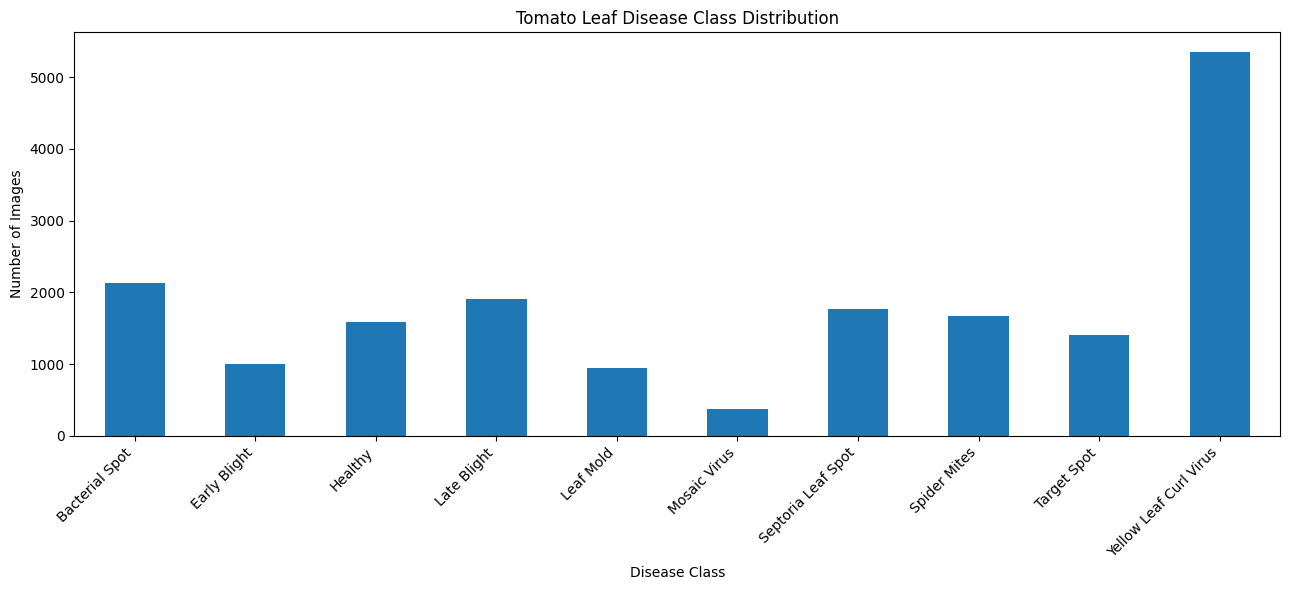

In [10]:
import matplotlib.pyplot as plt

class_counts = (
    df["label"]
    .value_counts()
    .sort_index()
)

display(
    class_counts.to_frame(
        "Number of Images"
    )
)

plt.figure(
    figsize=(13, 6)
)

class_counts.plot(
    kind="bar"
)

plt.title(
    "Tomato Leaf Disease Class Distribution"
)

plt.xlabel(
    "Disease Class"
)

plt.ylabel(
    "Number of Images"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

**Display Sample Images**


This cell displays one representative RGB image from each class. It verifies that the images and labels have been loaded correctly.

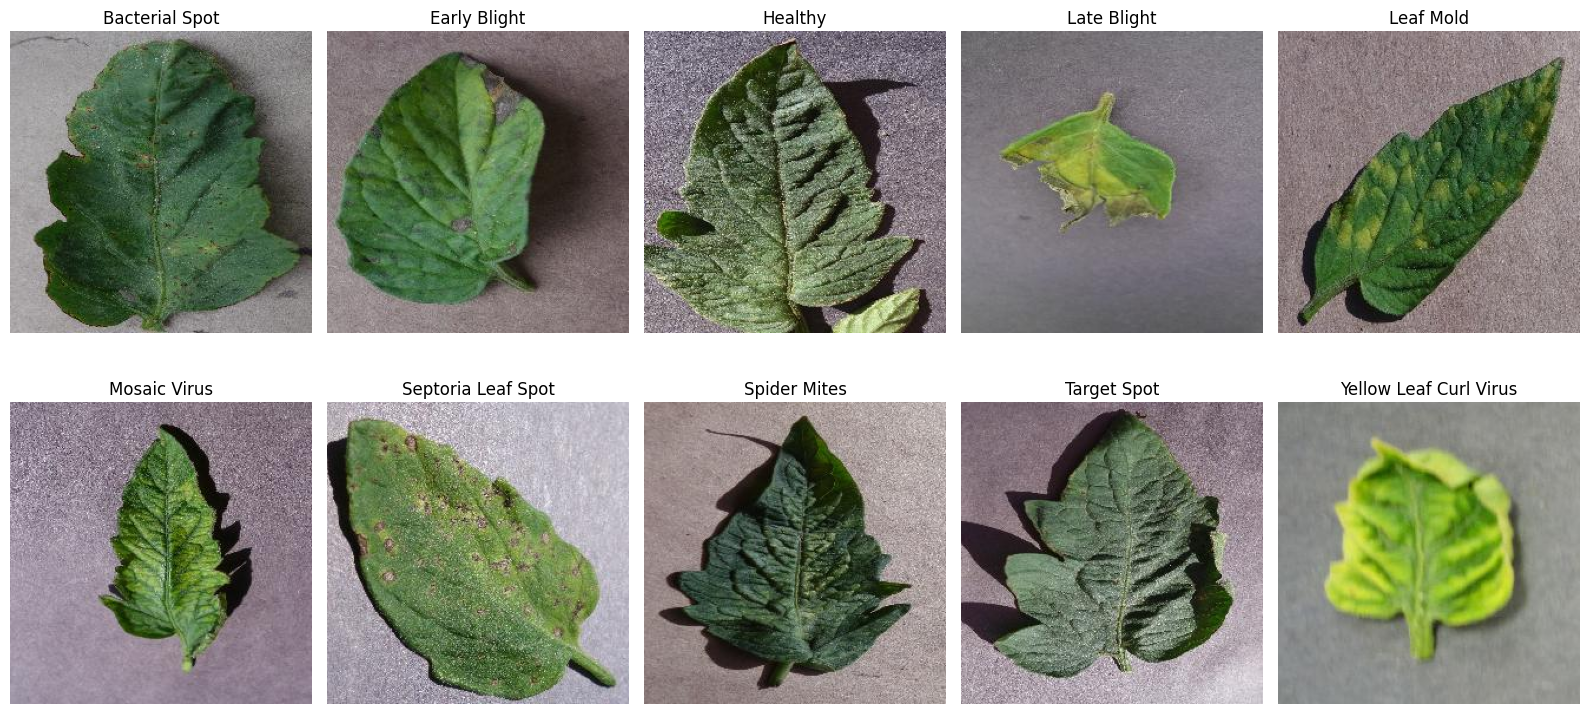

In [11]:
from PIL import Image

sample_df = (
    df.groupby("label")
      .sample(
          n=1,
          random_state=42
      )
)

plt.figure(
    figsize=(16, 8)
)

for i, (_, row) in enumerate(
    sample_df.iterrows()
):

    image = Image.open(
        row["filepath"]
    )

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(image)

    plt.title(
        row["label"]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

Machine-learning models cannot directly process text labels. Therefore, the 10 disease categories are converted into integer labels from 0 to 9.

In [12]:
class_names = sorted(
    df["label"].unique()
)

class_to_index = {

    name: i

    for i, name in enumerate(
        class_names
    )
}

index_to_class = {

    i: name

    for name, i in class_to_index.items()

}

NUM_CLASSES = len(
    class_names
)

print(
    "Number of classes:",
    NUM_CLASSES
)

print()

for i, name in enumerate(
    class_names
):

    print(
        i,
        "→",
        name
    )

Number of classes: 10

0 → Bacterial Spot
1 → Early Blight
2 → Healthy
3 → Late Blight
4 → Leaf Mold
5 → Mosaic Virus
6 → Septoria Leaf Spot
7 → Spider Mites
8 → Target Spot
9 → Yellow Leaf Curl Virus


**Create 80/10/10 Split**

We divide the 18,160 images into:

80% Training
10% Validation
10% Testing

A stratified split is used so that every class is represented proportionally in all three sets.

Most importantly, both Custom CNN and MobileNetV2 will use exactly these same datasets.

In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(

    df,

    test_size=0.20,

    stratify=df["label"],

    random_state=42
)


val_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    stratify=temp_df["label"],

    random_state=42
)


print(
    "Total images:",
    len(df)
)

print(
    "Training images:",
    len(train_df)
)

print(
    "Validation images:",
    len(val_df)
)

print(
    "Testing images:",
    len(test_df)
)


print("\nPercentages:")

print(
    f"Train: "
    f"{len(train_df)/len(df)*100:.2f}%"
)

print(
    f"Validation: "
    f"{len(val_df)/len(df)*100:.2f}%"
)

print(
    f"Test: "
    f"{len(test_df)/len(df)*100:.2f}%"
)

Total images: 18160
Training images: 14528
Validation images: 1816
Testing images: 1816

Percentages:
Train: 80.00%
Validation: 10.00%
Test: 10.00%


**Verify Stratified Split**

This table verifies that all 10 classes are represented in the training, validation and test datasets.

In [14]:
split_table = pd.DataFrame({

    "Train":
        train_df["label"].value_counts(),

    "Validation":
        val_df["label"].value_counts(),

    "Test":
        test_df["label"].value_counts()

}).fillna(0).astype(int)


display(
    split_table
)

,Train,Validation,Test
label,,,
Yellow Leaf Curl Virus,4286,536,535
Bacterial Spot,1702,213,212
Late Blight,1527,191,191
Septoria Leaf Spot,1417,177,177
Spider Mites,1341,167,168
Healthy,1273,159,159
Target Spot,1123,140,141
Early Blight,800,100,100
Leaf Mold,761,96,95


**Image Preprocessing**

Both models need a fixed image size. Therefore, every image is resized to 224 × 224 pixels with 3 RGB channels.

We use the same image size for both models so the comparison remains fair.

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (
    224,
    224
)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE


def load_image(
    filepath,
    label
):

    image = tf.io.read_file(
        filepath
    )

    image = tf.image.decode_image(

        image,

        channels=3,

        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

**TensorFlow Dataset Function**

This function converts our Pandas DataFrame into a TensorFlow data pipeline. Images are loaded efficiently in batches rather than loading all 18,160 images into RAM at once.

In [16]:
def dataframe_to_dataset(
    dataframe
):

    paths = dataframe[
        "filepath"
    ].values

    labels = (
        dataframe["label"]
        .map(class_to_index)
        .values
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                paths,
                labels
            )
        )
    )

    dataset = dataset.map(

        load_image,

        num_parallel_calls=AUTOTUNE
    )

    return dataset

**Create Train/Validation/Test Pipelines**


The datasets are batched into groups of 32 images. Only the training dataset is shuffled because validation and test predictions must remain in the same order as their DataFrames for correct metric calculation.

In [17]:
train_ds = dataframe_to_dataset(
    train_df
)

val_ds = dataframe_to_dataset(
    val_df
)

test_ds = dataframe_to_dataset(
    test_df
)


train_ds = (

    train_ds

    .shuffle(
        1000,
        seed=42
    )

    .batch(
        BATCH_SIZE
    )

    .prefetch(
        AUTOTUNE
    )
)


val_ds = (

    val_ds

    .batch(
        BATCH_SIZE
    )

    .prefetch(
        AUTOTUNE
    )
)


test_ds = (

    test_ds

    .batch(
        BATCH_SIZE
    )

    .prefetch(
        AUTOTUNE
    )
)


print(
    "TensorFlow datasets prepared successfully."
)

TensorFlow datasets prepared successfully.


Data augmentation creates realistic variations of training images. This helps the Custom CNN and MobileNetV2 generalize better to images that differ slightly from the training examples.

We use:

Horizontal flip

Rotation

Zoom

Contrast variation

In [18]:
data_augmentation = keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.15
    ),

    layers.RandomZoom(
        0.15
    ),

    layers.RandomContrast(
        0.10
    )

],
name="Data_Augmentation"
)

print(
    "Data augmentation pipeline created."
)

Data augmentation pipeline created.


**we're comparing.**

# Model 1

**Custom CNN**

No pretrained weights

Learns features from scratch

3 convolutional blocks

ReLU activation

MaxPooling

Dense classifier

Dropout

#Model 2

**MobileNetV2**

ImageNet pretrained

Feature extraction

Fine-tuning

Same 10 classes

Same train/validation/test

split

This makes the experiment a proper CNN vs Transfer Learning comparison.


The Custom CNN is trained from scratch. The convolutional layers learn disease-related features directly from the tomato images.

In [19]:
def build_custom_cnn():

    inputs = keras.Input(
        shape=(
            224,
            224,
            3
        )
    )


    # Data augmentation

    x = data_augmentation(
        inputs
    )


    # Normalize pixel values

    x = layers.Rescaling(
        1.0 / 255
    )(x)


    # Convolution Block 1

    x = layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)


    # Convolution Block 2

    x = layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)


    # Convolution Block 3

    x = layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        (2, 2)
    )(x)


    # Classification

    x = layers.Flatten()(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.5
    )(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = keras.Model(

        inputs,

        outputs,

        name="Custom_CNN"

    )


    return model


custom_cnn = build_custom_cnn()

custom_cnn.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,490 (24.86 MB)

 Trainable params: 6,516,490 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

**Compile Custom CNN**

Adam is used as the optimizer and sparse categorical cross-entropy is used as the loss function because the classes are integer encoded.

> Add blockquote



In [20]:
custom_cnn = build_custom_cnn()

In [21]:
custom_cnn.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [22]:
print(
    "Fresh learning rate:",
    float(
        keras.backend.get_value(
            custom_cnn.optimizer.learning_rate
        )
    )
)

Fresh learning rate: 0.0010000000474974513


**Training Callbacks**

Early stopping helps prevent unnecessary overtraining, while ReduceLROnPlateau lowers the learning rate when validation loss stops improving.

In [23]:

fresh_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

]

In [24]:
import time
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights for imbalanced datasets
y_train = train_df['label'].values
classes = np.array(class_names)
computed_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(computed_class_weights))

start_time_cnn = time.time()

history_cnn = custom_cnn.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    callbacks=fresh_callbacks,

    class_weight=class_weights,

    verbose=1

)

cnn_training_time = (
    time.time() - start_time_cnn
)

print("\n================================")
print("CUSTOM CNN TRAINING COMPLETED")
print("================================")

print(
    f"Training Time: "
    f"{cnn_training_time / 60:.2f} minutes"
)

print(
    f"Epochs completed: "
    f"{len(history_cnn.history['loss'])}"
)


Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 79s 148ms/step - accuracy: 0.4111 - loss: 1.8850 - val_accuracy: 0.5314 - val_loss: 1.2867 - learning_rate: 0.0010
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.6162 - loss: 1.2116 - val_accuracy: 0.7528 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.6861 - loss: 0.9682 - val_accuracy: 0.8348 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.7287 - loss: 0.8210 - val_accuracy: 0.8640 - val_loss: 0.4280 - learning_rate: 0.0010
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.7561 - loss: 0.7491 - val_accuracy: 0.8744 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 6/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.7740 - loss: 0.6808 - val_accuracy: 0.8392 - val_loss: 0.4591 - learning_rate: 0.0010
Epoch 7/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7983 - l

In [42]:
print(
    "Current learning rate:",
    float(
        keras.backend.get_value(
            custom_cnn.optimizer.learning_rate
        )
    )
)

Current learning rate: 2.700000004551839e-05


In [43]:
best_epoch = np.argmin(
    history_cnn.history["val_loss"]
) + 1

best_val_loss = min(
    history_cnn.history["val_loss"]
)

best_val_accuracy = (
    history_cnn.history["val_accuracy"][best_epoch - 1]
)

print("Best Epoch:", best_epoch)
print(
    f"Best Validation Loss: {best_val_loss:.4f}"
)
print(
    f"Validation Accuracy at Best Epoch: "
    f"{best_val_accuracy * 100:.2f}%"
)

Best Epoch: 18
Best Validation Loss: 0.1741
Validation Accuracy at Best Epoch: 94.05%


**Train Custom CNN**

This is the main training stage of the Custom CNN. We record the training time because training time is one of the required comparison parameters.

**CNN Evaluation**

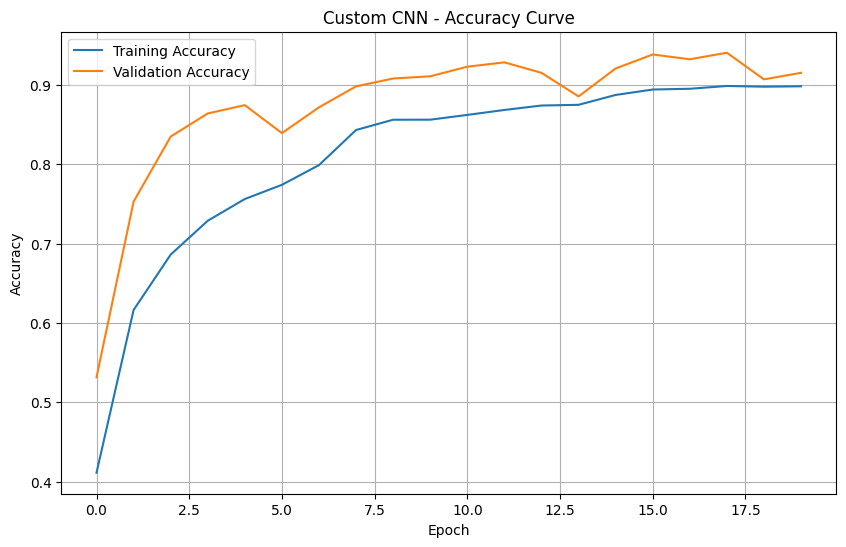

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Custom CNN - Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

**Loss Curve**

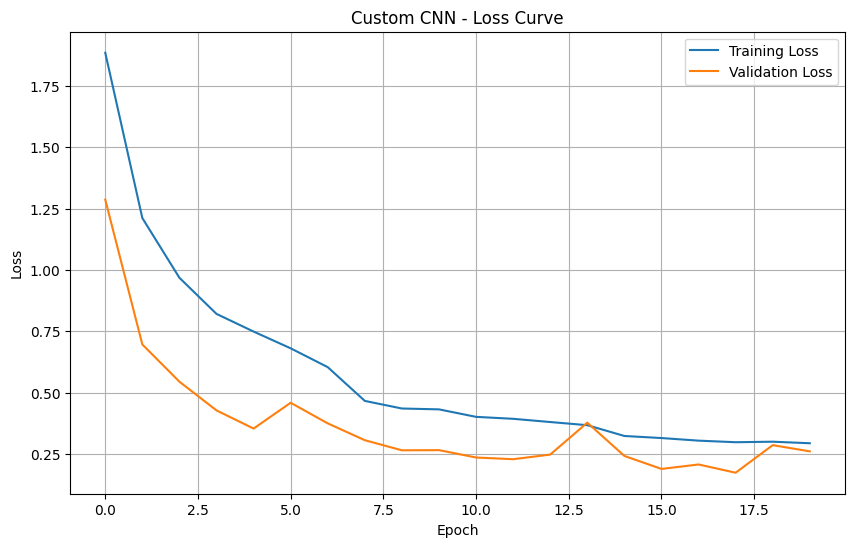

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("Custom CNN - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

**Test CNN**

In [29]:
cnn_test_loss, cnn_test_accuracy = custom_cnn.evaluate(
    test_ds,
    verbose=1
)

print("\n========== CUSTOM CNN RESULTS ==========")

print(
    f"Test Loss     : {cnn_test_loss:.4f}"
)

print(
    f"Test Accuracy : {cnn_test_accuracy:.4f}"
)

print(
    f"Test Accuracy : {cnn_test_accuracy * 100:.2f}%"
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.9389 - loss: 0.1800

========== CUSTOM CNN RESULTS ==========
Test Loss     : 0.1800
Test Accuracy : 0.9389
Test Accuracy : 93.89%


**CNN Predictions**

In [30]:
cnn_probabilities = custom_cnn.predict(
    test_ds
)

cnn_predictions = np.argmax(
    cnn_probabilities,
    axis=1
)

cnn_actual = (
    test_df["label"]
    .map(class_to_index)
    .values
)

print(
    "Number of predictions:",
    len(cnn_predictions)
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
Number of predictions: 1816


**CNN Metrics**

In [31]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

cnn_precision = precision_score(
    cnn_actual,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

cnn_recall = recall_score(
    cnn_actual,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

cnn_f1 = f1_score(
    cnn_actual,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

print("========== CUSTOM CNN METRICS ==========")

print(f"Accuracy  : {cnn_test_accuracy:.4f}")
print(f"Precision : {cnn_precision:.4f}")
print(f"Recall    : {cnn_recall:.4f}")
print(f"F1-score  : {cnn_f1:.4f}")

========== CUSTOM CNN METRICS ==========
Accuracy  : 0.9389
Precision : 0.9411
Recall    : 0.9389
F1-score  : 0.9392


**Classification Report**

In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        cnn_actual,
        cnn_predictions,
        target_names=class_names,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

        Bacterial Spot       0.98      0.93      0.96       212
          Early Blight       0.92      0.88      0.90       100
               Healthy       0.93      1.00      0.96       159
           Late Blight       0.95      0.91      0.93       191
             Leaf Mold       0.92      0.97      0.94        95
          Mosaic Virus       0.81      1.00      0.89        38
    Septoria Leaf Spot       0.98      0.92      0.95       177
          Spider Mites       0.87      0.88      0.87       168
           Target Spot       0.84      0.92      0.88       141
Yellow Leaf Curl Virus       0.98      0.97      0.97       535

              accuracy                           0.94      1816
             macro avg       0.92      0.94      0.93      1816
          weighted avg       0.94      0.94      0.94      1816



**Confusion Matrix**

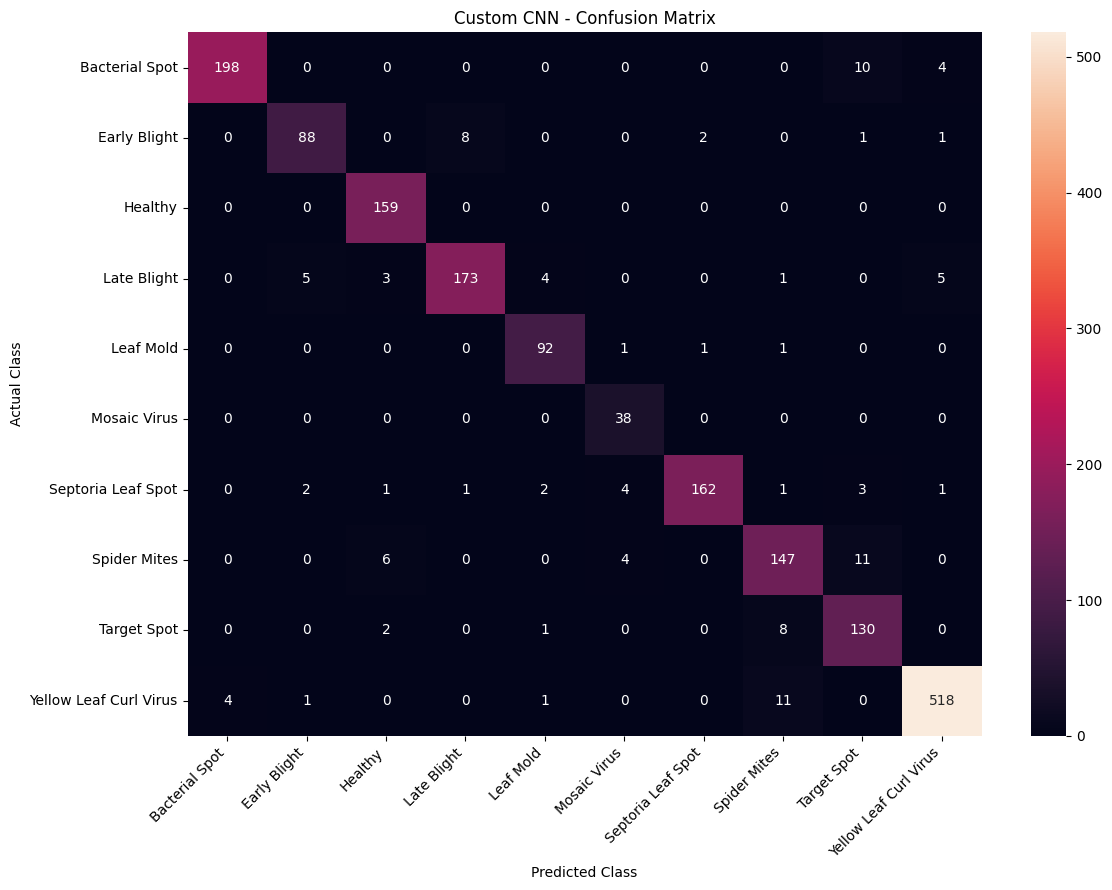

In [33]:
from sklearn.metrics import confusion_matrix

cnn_cm = confusion_matrix(
    cnn_actual,
    cnn_predictions
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Custom CNN - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

**CNN Parameters**

In [34]:
cnn_total_params = (
    custom_cnn.count_params()
)

cnn_trainable_params = sum(
    np.prod(variable.shape)
    for variable in custom_cnn.trainable_weights
)

print(
    "Custom CNN Total Parameters:",
    f"{cnn_total_params:,}"
)

print(
    "Custom CNN Trainable Parameters:",
    f"{cnn_trainable_params:,}"
)

Custom CNN Total Parameters: 6,516,490
Custom CNN Trainable Parameters: 6,516,490


**Store CNN Results**

In [35]:
cnn_results = {

    "Model":
        "Custom CNN",

    "Accuracy":
        cnn_test_accuracy,

    "Precision":
        cnn_precision,

    "Recall":
        cnn_recall,

    "F1 Score":
        cnn_f1,

    "Training Time (min)":
        cnn_training_time / 60,

    "Total Parameters":
        cnn_total_params,

    "Trainable Parameters":
        cnn_trainable_params

}

display(
    pd.DataFrame([cnn_results])
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Total Parameters,Trainable Parameters
0,Custom CNN,0.938877,0.941098,0.938877,0.939212,12.704813,6516490,6516490


**3 PRETRAINED MODELS**

This cell imports the three pretrained CNN architectures. All three models use ImageNet pretrained weights and will be adapted to the 10-class tomato disease classification problem.

In [36]:
from tensorflow.keras.applications import (
    MobileNetV2,
    ResNet50,
    EfficientNetB0
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

from tensorflow.keras.applications.efficientnet import (
    preprocess_input as efficientnet_preprocess
)

print("MobileNetV2, ResNet50 and EfficientNetB0 imported successfully.")

MobileNetV2, ResNet50 and EfficientNetB0 imported successfully.


**Why MobileNetV2?**

MobileNetV2 is selected because it is a lightweight pretrained CNN that provides a good balance between classification performance and computational efficiency.

## MobileNetV2 – Model Selection

MobileNetV2 is a lightweight convolutional neural network pretrained on the ImageNet dataset.

It was selected because:

1. It uses pretrained ImageNet features.
2. It is computationally efficient.
3. It has relatively low model complexity.
4. It is suitable for resource-constrained applications.
5. It supports both feature extraction and fine-tuning.

For this experiment, the pretrained convolutional base is first frozen for feature extraction. Later, selected deeper layers are unfrozen for fine-tuning on tomato leaf disease images.

**Load MobileNetV2**

In [37]:
mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_base.trainable = False

print("MobileNetV2 loaded successfully.")
print("Pretrained base trainable:", mobilenet_base.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded successfully.
Pretrained base trainable: False


**Build MobileNetV2**

The pretrained MobileNetV2 acts as a feature extractor. Global Average Pooling converts the extracted feature maps into a compact representation, followed by a new classifier for our 10 classes.

In [38]:
inputs = keras.Input(
    shape=(224, 224, 3)
)

# Data augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = mobilenet_preprocess(x)

# Pretrained feature extractor
x = mobilenet_base(
    x,
    training=False
)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Classification head
x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(
    0.4
)(x)

# 10 tomato classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenet_model = keras.Model(
    inputs,
    outputs,
    name="MobileNetV2_Tomato"
)

mobilenet_model.summary()

Model: "MobileNetV2_Tomato"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Compile MobileNetV2**

During the feature-extraction stage, the pretrained base is frozen and only the newly added classification layers are trained.

In [39]:
mobilenet_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print(
    "MobileNetV2 compiled successfully."
)

MobileNetV2 compiled successfully.


**MobileNetV2 Feature Extraction**


In this stage, the ImageNet pretrained layers remain frozen. The model learns how to map the pretrained features to the 10 tomato disease classes.

In [44]:
mobilenet_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

start_time_mobilenet_feature = time.time()

history_mobilenet_feature = mobilenet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    callbacks=mobilenet_callbacks,

    class_weight=class_weights,

    verbose=1
)

mobilenet_feature_time = (
    time.time() - start_time_mobilenet_feature
)

print(
    "\n======================================"
)

print(
    "MOBILENETV2 FEATURE EXTRACTION DONE"
)

print(
    "======================================"
)

print(
    f"Training Time: "
    f"{mobilenet_feature_time / 60:.2f} minutes"
)

Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - accuracy: 0.9036 - loss: 0.3191 - val_accuracy: 0.9080 - val_loss: 0.2836 - learning_rate: 9.0000e-05
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - accuracy: 0.9045 - loss: 0.3158 - val_accuracy: 0.9075 - val_loss: 0.2788 - learning_rate: 9.0000e-05
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - accuracy: 0.9035 - loss: 0.3189 - val_accuracy: 0.9053 - val_loss: 0.2768 - learning_rate: 9.0000e-05
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.9045 - loss: 0.3055 - val_accuracy: 0.9042 - val_loss: 0.2828 - learning_rate: 9.0000e-05
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9063 - loss: 0.3032
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
454/454 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.9060 - loss: 0.3013 - val_accuracy: 0.9064 - val_loss: 0.2841 - learning_rate: 9.0000e-05
Epoch 6/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - ac

CELL 38 — MobileNetV2 Fine-Tuning

Note:
The final 30 layers of the pretrained MobileNetV2 are unfrozen and fine-tuned with a low learning rate so the model can adapt its learned features to tomato leaf disease patterns.

In [45]:
# Unfreeze MobileNetV2 for fine-tuning
mobilenet_base.trainable = True

# Keep the early layers frozen
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

print(
    "Trainable MobileNetV2 layers:",
    sum(
        layer.trainable
        for layer in mobilenet_base.layers
    )
)

# Recompile with a small learning rate
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Fresh callbacks for fine-tuning
mobilenet_ft_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Start fine-tuning
start_time_mobilenet_ft = time.time()

history_mobilenet_ft = mobilenet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    callbacks=mobilenet_ft_callbacks,

    class_weight=class_weights,

    verbose=1
)

mobilenet_ft_time = (
    time.time() - start_time_mobilenet_ft
)

mobilenet_total_time = (
    mobilenet_feature_time +
    mobilenet_ft_time
)

print("\n================================")
print("MOBILENETV2 FINE-TUNING COMPLETED")
print("================================")

print(
    f"Total Training Time: "
    f"{mobilenet_total_time / 60:.2f} minutes"
)

Trainable MobileNetV2 layers: 30
Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 57s 100ms/step - accuracy: 0.7179 - loss: 0.9664 - val_accuracy: 0.9091 - val_loss: 0.2784 - learning_rate: 1.0000e-05
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.8475 - loss: 0.4828 - val_accuracy: 0.9080 - val_loss: 0.2750 - learning_rate: 1.0000e-05
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.8672 - loss: 0.4153 - val_accuracy: 0.9075 - val_loss: 0.2818 - learning_rate: 1.0000e-05
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8878 - loss: 0.3613
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
454/454 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.8890 - loss: 0.3627 - val_accuracy: 0.9113 - val_loss: 0.2828 - learning_rate: 1.0000e-05
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.8950 - loss: 0.3355 - val_accuracy: 0.9163 - val_loss: 0.2729 - learning_rate: 3.0000e-06
Epoch 6/10
454/454 ━━━━

**MobileNetV2 Training Curves**

Note:
The training and validation accuracy and loss curves are plotted to analyze the learning behavior of MobileNetV2 and identify possible overfitting.

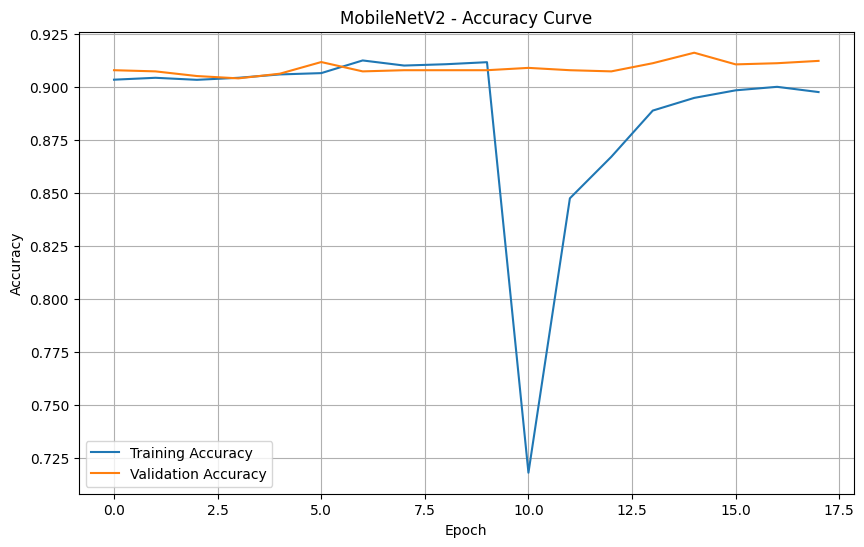

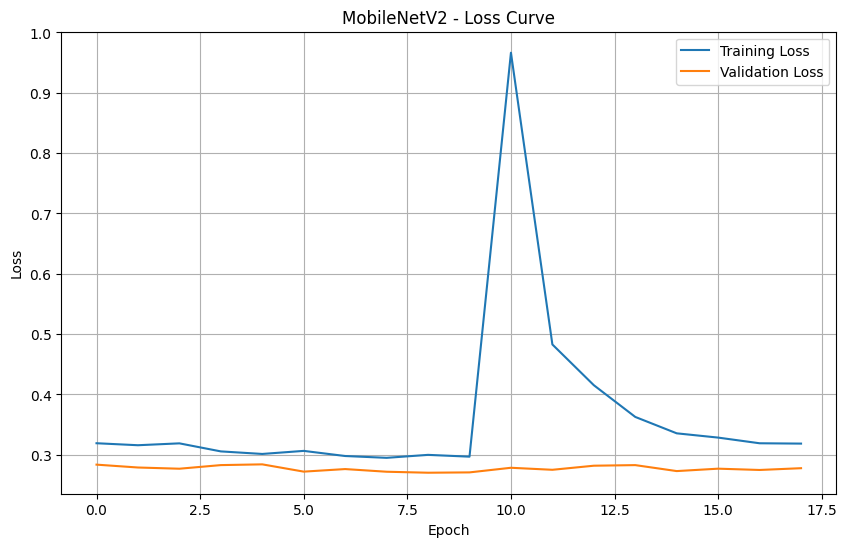

In [46]:
# Combine feature extraction and fine-tuning histories

mobilenet_accuracy = (
    history_mobilenet_feature.history["accuracy"]
    +
    history_mobilenet_ft.history["accuracy"]
)

mobilenet_val_accuracy = (
    history_mobilenet_feature.history["val_accuracy"]
    +
    history_mobilenet_ft.history["val_accuracy"]
)

mobilenet_loss = (
    history_mobilenet_feature.history["loss"]
    +
    history_mobilenet_ft.history["loss"]
)

mobilenet_val_loss = (
    history_mobilenet_feature.history["val_loss"]
    +
    history_mobilenet_ft.history["val_loss"]
)


# Accuracy Curve
plt.figure(figsize=(10, 6))

plt.plot(
    mobilenet_accuracy,
    label="Training Accuracy"
)

plt.plot(
    mobilenet_val_accuracy,
    label="Validation Accuracy"
)

plt.title(
    "MobileNetV2 - Accuracy Curve"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()


# Loss Curve
plt.figure(figsize=(10, 6))

plt.plot(
    mobilenet_loss,
    label="Training Loss"
)

plt.plot(
    mobilenet_val_loss,
    label="Validation Loss"
)

plt.title(
    "MobileNetV2 - Loss Curve"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

**— MobileNetV2 Predictions & Metrics**

Note:
Predictions from the unseen test set are used to calculate accuracy, weighted precision, recall, and F1-score for the final MobileNetV2 evaluation.

In [47]:
# Evaluate MobileNetV2 on the test dataset

mobilenet_test_loss, mobilenet_test_accuracy = (
    mobilenet_model.evaluate(
        test_ds,
        verbose=1
    )
)


# Generate test predictions

mobilenet_probabilities = (
    mobilenet_model.predict(test_ds)
)

mobilenet_predictions = np.argmax(
    mobilenet_probabilities,
    axis=1
)

mobilenet_actual = (
    test_df["label"]
    .map(class_to_index)
    .values
)


# Calculate evaluation metrics

mobilenet_precision = precision_score(
    mobilenet_actual,
    mobilenet_predictions,
    average="weighted",
    zero_division=0
)

mobilenet_recall = recall_score(
    mobilenet_actual,
    mobilenet_predictions,
    average="weighted",
    zero_division=0
)

mobilenet_f1 = f1_score(
    mobilenet_actual,
    mobilenet_predictions,
    average="weighted",
    zero_division=0
)


print("\n================================")
print("MOBILENETV2 TEST RESULTS")
print("================================")

print(
    f"Accuracy  : "
    f"{mobilenet_test_accuracy * 100:.2f}%"
)

print(
    f"Precision : "
    f"{mobilenet_precision * 100:.2f}%"
)

print(
    f"Recall    : "
    f"{mobilenet_recall * 100:.2f}%"
)

print(
    f"F1-score  : "
    f"{mobilenet_f1 * 100:.2f}%"
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9058 - loss: 0.2829
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step

MOBILENETV2 TEST RESULTS
Accuracy  : 90.58%
Precision : 91.06%
Recall    : 90.58%
F1-score  : 90.56%


**MobileNetV2 Results & Confusion Matrix**

Note:
The final MobileNetV2 metrics, model complexity, and confusion matrix are presented to evaluate overall and class-wise performance.

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Total Parameters,Trainable Parameters
0,MobileNetV2,0.905837,0.910608,0.905837,0.905597,12.572431,2423242,1691658


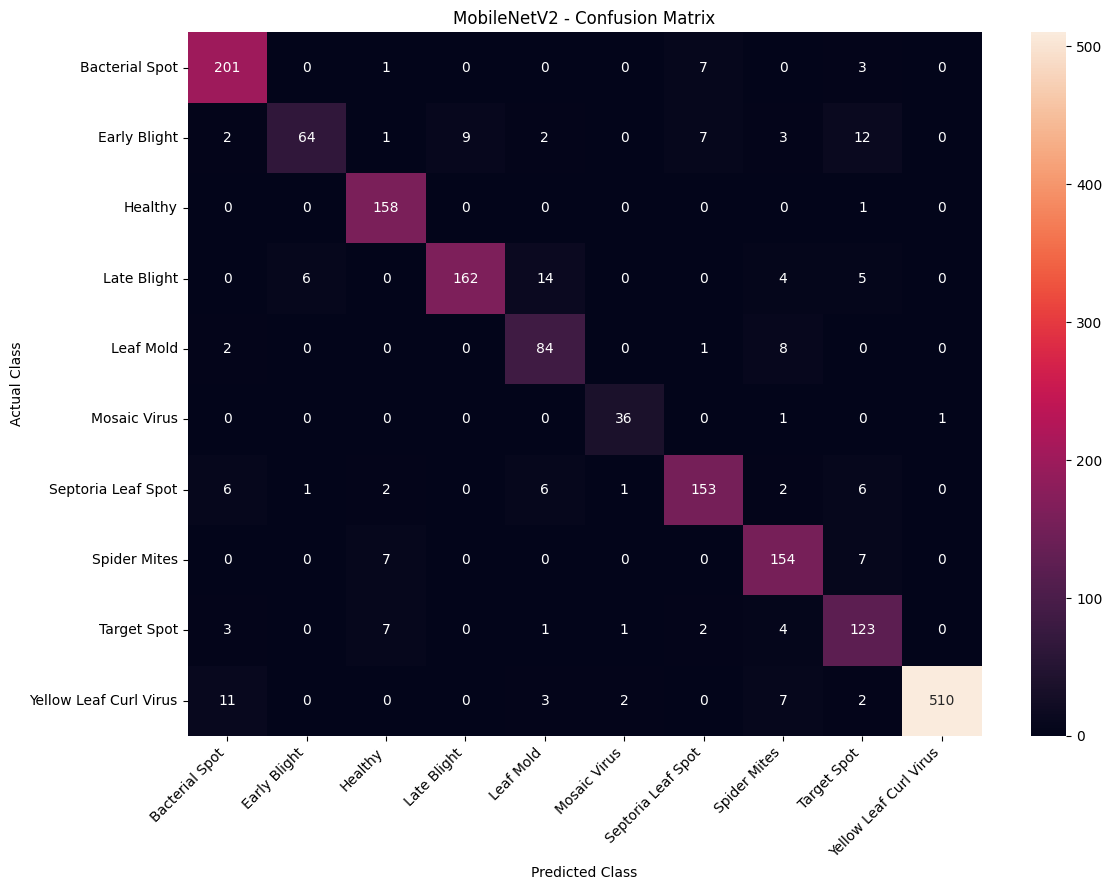

In [48]:
# Calculate model parameters

mobilenet_total_params = (
    mobilenet_model.count_params()
)

mobilenet_trainable_params = sum(
    np.prod(variable.shape)
    for variable in
    mobilenet_model.trainable_weights
)

# Evaluate the model on the test dataset
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=0
)

# Make predictions on the test dataset
mobilenet_probabilities = mobilenet_model.predict(
    test_ds
)
mobilenet_predictions = np.argmax(
    mobilenet_probabilities,
    axis=1
)

# Get actual labels from test_df
mobilenet_actual = (
    test_df["label"]
    .map(class_to_index)
    .values
)

# Calculate metrics
mobilenet_precision = precision_score(
    mobilenet_actual,
    mobilenet_predictions,
    average="weighted",
    zero_division=0
)
mobilenet_recall = recall_score(
    mobilenet_actual,
    mobilenet_predictions,
    average="weighted",
    zero_division=0
)
mobilenet_f1 = f1_score(
    mobilenet_actual,
    mobilenet_predictions,
    average="weighted",
    zero_division=0
)



# Store results for final comparison

mobilenet_results = {

    "Model":
        "MobileNetV2",

    "Accuracy":
        mobilenet_test_accuracy,

    "Precision":
        mobilenet_precision,

    "Recall":
        mobilenet_recall,

    "F1 Score":
        mobilenet_f1,

    "Training Time (min)":
        mobilenet_total_time / 60,

    "Total Parameters":
        mobilenet_total_params,

    "Trainable Parameters":
        mobilenet_trainable_params
}


display(
    pd.DataFrame([
        mobilenet_results
    ])
)


# Confusion Matrix

mobilenet_cm = confusion_matrix(
    mobilenet_actual,
    mobilenet_predictions
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    mobilenet_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "MobileNetV2 - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

**ResNet50**

ResNet50 Setup & Feature Extraction

Note:
ResNet50 is selected because its residual connections allow deep feature extraction while reducing the degradation problem associated with deeper networks. The ImageNet-pretrained base is initially frozen for feature extraction.

In [49]:
# Load ResNet50 with pretrained ImageNet weights
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers for feature extraction
resnet_base.trainable = False


# Build ResNet50 transfer-learning model
inputs = keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

# ResNet50 preprocessing
x = resnet_preprocess(x)

# Pretrained feature extractor
x = resnet_base(
    x,
    training=False
)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Classification head
x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(
    0.4
)(x)

# 10 tomato disease classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

resnet_model = keras.Model(
    inputs,
    outputs,
    name="ResNet50_Tomato"
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ResNet50_Tomato"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Data_Augmentation   │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ Data_Augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ Data_Augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ Data_Augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │      1,290 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

**ResNet50 Training & Fine-Tuning**

Note:
The ResNet50 model is first trained with its pretrained layers frozen and then fine-tuned by unfreezing the deeper layers using a low learning rate.

In [50]:
# Compile for feature extraction
resnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


# Stage 1: Feature extraction
start_time_resnet = time.time()

history_resnet_feature = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=resnet_callbacks,
    class_weight=class_weights,
    verbose=1
)

resnet_feature_time = (
    time.time() - start_time_resnet
)


# Stage 2: Fine-tuning
resnet_base.trainable = True

# Keep early layers frozen
for layer in resnet_base.layers[:-30]:
    layer.trainable = False


# Recompile with a smaller learning rate
resnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


resnet_ft_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]


start_time_resnet_ft = time.time()

history_resnet_ft = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=resnet_ft_callbacks,
    class_weight=class_weights,
    verbose=1
)

resnet_ft_time = (
    time.time() - start_time_resnet_ft
)

resnet_total_time = (
    resnet_feature_time +
    resnet_ft_time
)


print("\n================================")
print("RESNET50 TRAINING COMPLETED")
print("================================")

print(
    f"Total Training Time: "
    f"{resnet_total_time / 60:.2f} minutes"
)

Epoch 1/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 88s 174ms/step - accuracy: 0.7702 - loss: 0.7836 - val_accuracy: 0.8354 - val_loss: 0.5003 - learning_rate: 0.0010
Epoch 2/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 76s 164ms/step - accuracy: 0.8858 - loss: 0.3942 - val_accuracy: 0.8794 - val_loss: 0.3401 - learning_rate: 0.0010
Epoch 3/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 75s 164ms/step - accuracy: 0.9048 - loss: 0.3144 - val_accuracy: 0.8888 - val_loss: 0.3296 - learning_rate: 0.0010
Epoch 4/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 76s 164ms/step - accuracy: 0.9151 - loss: 0.2752 - val_accuracy: 0.8844 - val_loss: 0.3517 - learning_rate: 0.0010
Epoch 5/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 75s 164ms/step - accuracy: 0.9209 - loss: 0.2548 - val_accuracy: 0.8981 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 6/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 78s 169ms/step - accuracy: 0.9298 - loss: 0.2386 - val_accuracy: 0.9229 - val_loss: 0.2326 - learning_rate: 0.0010
Epoch 7/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 75s 163ms/step - accuracy: 0.9335 - l

**ResNet50 Training Curves**

Note:
The training and validation curves from both feature extraction and fine-tuning are combined to analyze ResNet50's learning behavior.

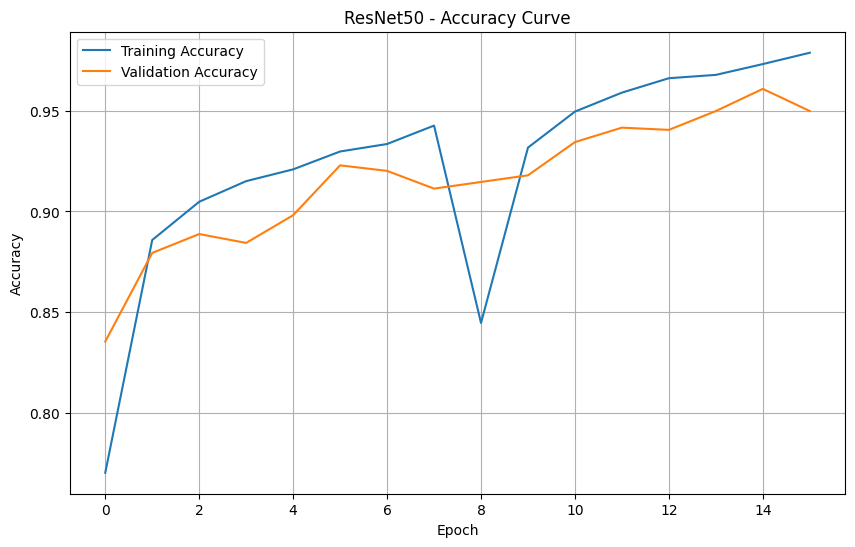

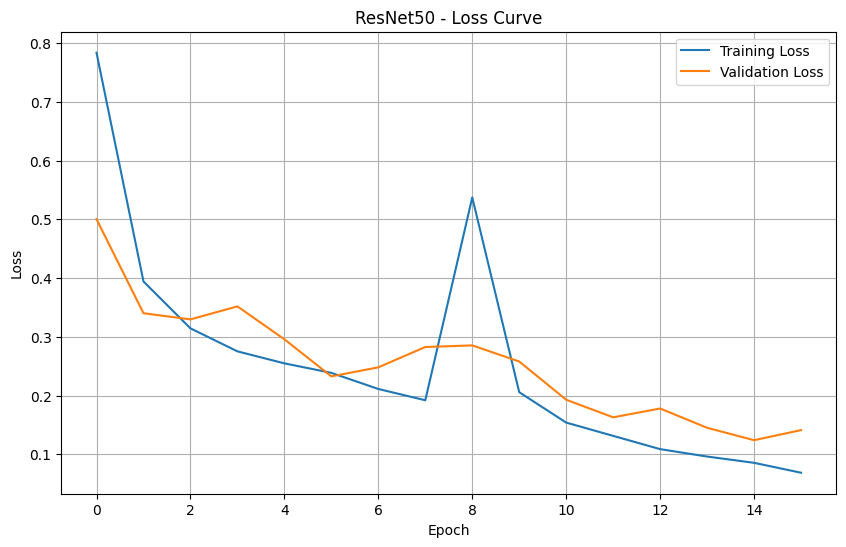

In [51]:
# Combine both training stages

resnet_accuracy = (
    history_resnet_feature.history["accuracy"]
    +
    history_resnet_ft.history["accuracy"]
)

resnet_val_accuracy = (
    history_resnet_feature.history["val_accuracy"]
    +
    history_resnet_ft.history["val_accuracy"]
)

resnet_loss = (
    history_resnet_feature.history["loss"]
    +
    history_resnet_ft.history["loss"]
)

resnet_val_loss = (
    history_resnet_feature.history["val_loss"]
    +
    history_resnet_ft.history["val_loss"]
)


# Accuracy curve
plt.figure(figsize=(10, 6))

plt.plot(
    resnet_accuracy,
    label="Training Accuracy"
)

plt.plot(
    resnet_val_accuracy,
    label="Validation Accuracy"
)

plt.title(
    "ResNet50 - Accuracy Curve"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()


# Loss curve
plt.figure(figsize=(10, 6))

plt.plot(
    resnet_loss,
    label="Training Loss"
)

plt.plot(
    resnet_val_loss,
    label="Validation Loss"
)

plt.title(
    "ResNet50 - Loss Curve"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

**ResNet50 Evaluation & Results**

Note:
Predictions from the unseen test set are used to calculate accuracy, weighted precision, recall, and F1-score. The confusion matrix shows class-wise prediction performance.

57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.9548 - loss: 0.1420
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 180ms/step

RESNET50 TEST RESULTS
Accuracy  : 95.48%
Precision : 95.64%
Recall    : 95.48%
F1-score  : 95.51%


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Total Parameters,Trainable Parameters
0,ResNet50,0.954846,0.956363,0.954846,0.955059,23.644513,23851274,14713738


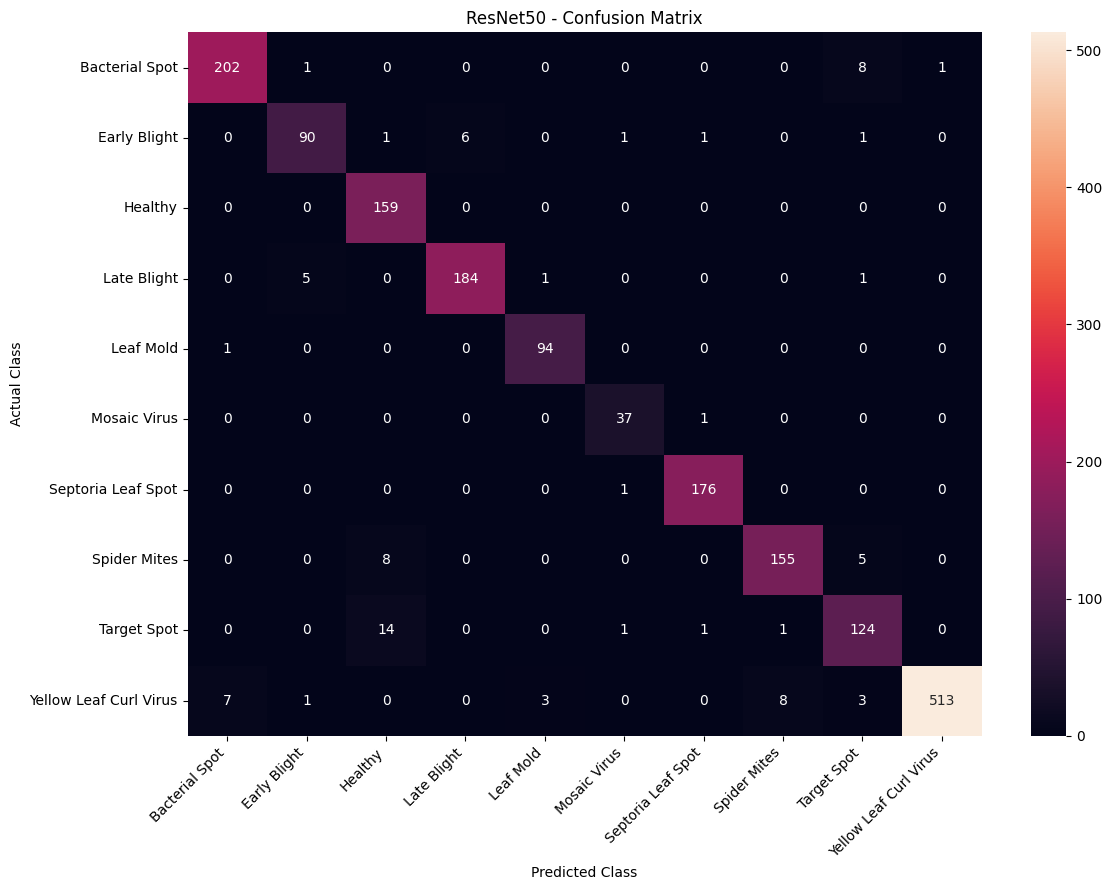

In [52]:
# Test evaluation
resnet_test_loss, resnet_test_accuracy = (
    resnet_model.evaluate(
        test_ds,
        verbose=1
    )
)


# Generate predictions
resnet_probabilities = (
    resnet_model.predict(test_ds)
)

resnet_predictions = np.argmax(
    resnet_probabilities,
    axis=1
)

resnet_actual = (
    test_df["label"]
    .map(class_to_index)
    .values
)


# Calculate metrics
resnet_precision = precision_score(
    resnet_actual,
    resnet_predictions,
    average="weighted",
    zero_division=0
)

resnet_recall = recall_score(
    resnet_actual,
    resnet_predictions,
    average="weighted",
    zero_division=0
)

resnet_f1 = f1_score(
    resnet_actual,
    resnet_predictions,
    average="weighted",
    zero_division=0
)


# Model parameters
resnet_total_params = (
    resnet_model.count_params()
)

resnet_trainable_params = sum(
    np.prod(variable.shape)
    for variable in
    resnet_model.trainable_weights
)


# Store results
resnet_results = {

    "Model":
        "ResNet50",

    "Accuracy":
        resnet_test_accuracy,

    "Precision":
        resnet_precision,

    "Recall":
        resnet_recall,

    "F1 Score":
        resnet_f1,

    "Training Time (min)":
        resnet_total_time / 60,

    "Total Parameters":
        resnet_total_params,

    "Trainable Parameters":
        resnet_trainable_params
}


print("\n================================")
print("RESNET50 TEST RESULTS")
print("================================")

print(
    f"Accuracy  : "
    f"{resnet_test_accuracy * 100:.2f}%"
)

print(
    f"Precision : "
    f"{resnet_precision * 100:.2f}%"
)

print(
    f"Recall    : "
    f"{resnet_recall * 100:.2f}%"
)

print(
    f"F1-score  : "
    f"{resnet_f1 * 100:.2f}%"
)

display(
    pd.DataFrame([
        resnet_results
    ])
)


# Confusion matrix
resnet_cm = confusion_matrix(
    resnet_actual,
    resnet_predictions
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "ResNet50 - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

**EfficientNetB0**

CELL 46 — EfficientNetB0 Setup & Feature Extraction

Note:
EfficientNetB0 is selected because it provides an efficient balance between classification performance and computational complexity. Its ImageNet-pretrained base is initially frozen for feature extraction.

In [53]:
# Load EfficientNetB0 with pretrained ImageNet weights
efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
efficientnet_base.trainable = False


# Build EfficientNetB0 transfer-learning model
inputs = keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

# EfficientNet preprocessing
x = efficientnet_preprocess(x)

# Pretrained feature extractor
x = efficientnet_base(
    x,
    training=False
)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Classification head
x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(
    0.4
)(x)

# 10 tomato disease classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

efficientnet_model = keras.Model(
    inputs,
    outputs,
    name="EfficientNetB0_Tomato"
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_Tomato"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

EfficientNetB0 Training & Fine-Tuning

Note:
EfficientNetB0 is first trained as a frozen feature extractor and then fine-tuned by unfreezing its deeper layers with a small learning rate.

In [54]:
# Compile for feature extraction
efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


# Stage 1: Feature extraction
start_time_efficientnet = time.time()

history_efficientnet_feature = (
    efficientnet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        callbacks=efficientnet_callbacks,
        class_weight=class_weights,
        verbose=1
    )
)

efficientnet_feature_time = (
    time.time() - start_time_efficientnet
)


# Stage 2: Fine-tuning
efficientnet_base.trainable = True

# Keep early layers frozen
for layer in efficientnet_base.layers[:-30]:
    layer.trainable = False


# Recompile with a low learning rate
efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


efficientnet_ft_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]


start_time_efficientnet_ft = time.time()

history_efficientnet_ft = (
    efficientnet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        callbacks=efficientnet_ft_callbacks,
        class_weight=class_weights,
        verbose=1
    )
)

efficientnet_ft_time = (
    time.time() - start_time_efficientnet_ft
)

efficientnet_total_time = (
    efficientnet_feature_time +
    efficientnet_ft_time
)

print("\n================================")
print("EFFICIENTNETB0 TRAINING COMPLETED")
print("================================")

print(
    f"Total Training Time: "
    f"{efficientnet_total_time / 60:.2f} minutes"
)

Epoch 1/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 58s 103ms/step - accuracy: 0.7393 - loss: 0.8564 - val_accuracy: 0.8783 - val_loss: 0.3935 - learning_rate: 0.0010
Epoch 2/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.8650 - loss: 0.4576 - val_accuracy: 0.8921 - val_loss: 0.3303 - learning_rate: 0.0010
Epoch 3/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.8873 - loss: 0.3652 - val_accuracy: 0.9069 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 4/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9043 - loss: 0.3146 - val_accuracy: 0.9146 - val_loss: 0.2541 - learning_rate: 0.0010
Epoch 5/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - accuracy: 0.9130 - loss: 0.2915 - val_accuracy: 0.9207 - val_loss: 0.2368 - learning_rate: 0.0010
Epoch 6/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.9185 - loss: 0.2668 - val_accuracy: 0.9080 - val_loss: 0.2660 - learning_rate: 0.0010
Epoch 7/8
454/454 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.9211 - loss: 0

EfficientNetB0 Evaluation & Results

Note:
Predictions from the unseen test set are used to calculate accuracy, weighted precision, recall, and F1-score. The confusion matrix provides class-wise evaluation of the model.

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9317 - loss: 0.1938
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step

EFFICIENTNETB0 TEST RESULTS
Accuracy  : 93.17%
Precision : 93.81%
Recall    : 93.17%
F1-score  : 93.30%


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Total Parameters,Trainable Parameters
0,EfficientNetB0,0.931718,0.938101,0.931718,0.932957,14.939847,4214829,1661418


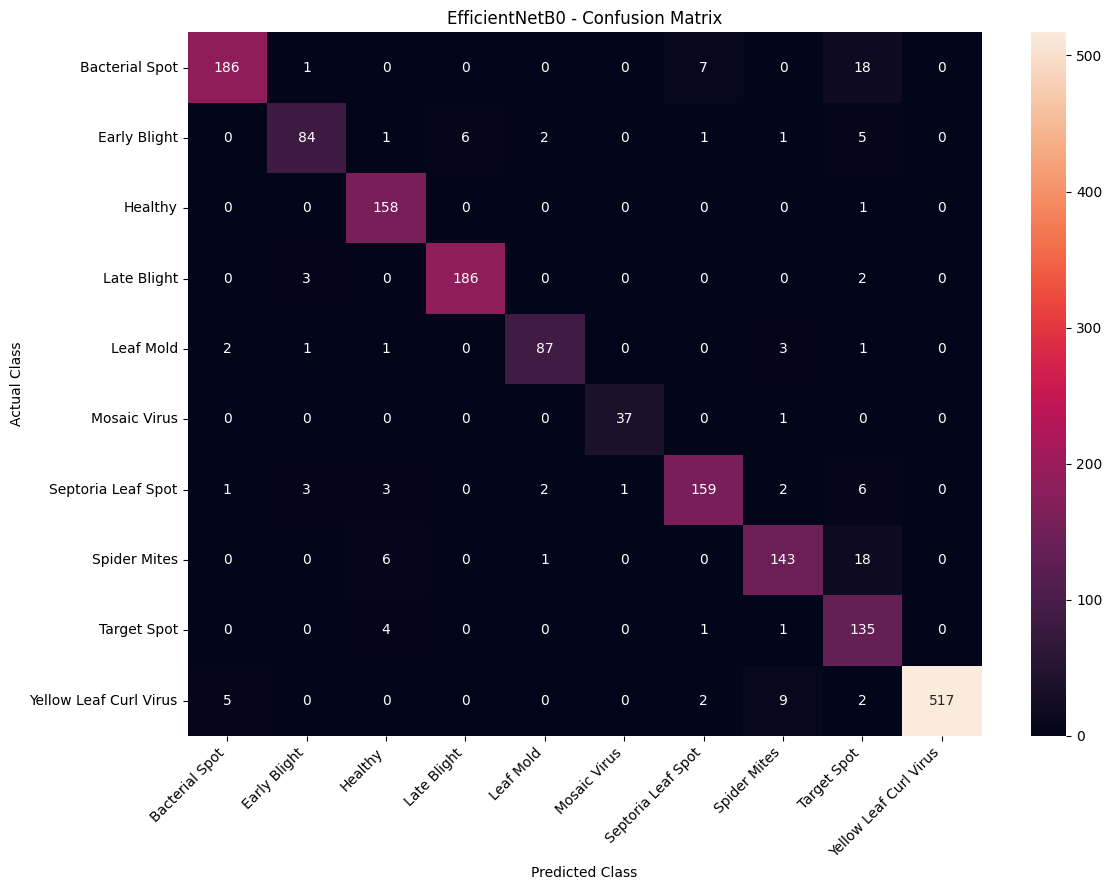

In [55]:
# Test evaluation
efficientnet_test_loss, efficientnet_test_accuracy = (
    efficientnet_model.evaluate(
        test_ds,
        verbose=1
    )
)


# Generate predictions
efficientnet_probabilities = (
    efficientnet_model.predict(test_ds)
)

efficientnet_predictions = np.argmax(
    efficientnet_probabilities,
    axis=1
)

efficientnet_actual = (
    test_df["label"]
    .map(class_to_index)
    .values
)


# Calculate metrics
efficientnet_precision = precision_score(
    efficientnet_actual,
    efficientnet_predictions,
    average="weighted",
    zero_division=0
)

efficientnet_recall = recall_score(
    efficientnet_actual,
    efficientnet_predictions,
    average="weighted",
    zero_division=0
)

efficientnet_f1 = f1_score(
    efficientnet_actual,
    efficientnet_predictions,
    average="weighted",
    zero_division=0
)


# Model parameters
efficientnet_total_params = (
    efficientnet_model.count_params()
)

efficientnet_trainable_params = sum(
    np.prod(variable.shape)
    for variable in
    efficientnet_model.trainable_weights
)


# Store results
efficientnet_results = {

    "Model":
        "EfficientNetB0",

    "Accuracy":
        efficientnet_test_accuracy,

    "Precision":
        efficientnet_precision,

    "Recall":
        efficientnet_recall,

    "F1 Score":
        efficientnet_f1,

    "Training Time (min)":
        efficientnet_total_time / 60,

    "Total Parameters":
        efficientnet_total_params,

    "Trainable Parameters":
        efficientnet_trainable_params
}


print("\n================================")
print("EFFICIENTNETB0 TEST RESULTS")
print("================================")

print(
    f"Accuracy  : "
    f"{efficientnet_test_accuracy * 100:.2f}%"
)

print(
    f"Precision : "
    f"{efficientnet_precision * 100:.2f}%"
)

print(
    f"Recall    : "
    f"{efficientnet_recall * 100:.2f}%"
)

print(
    f"F1-score  : "
    f"{efficientnet_f1 * 100:.2f}%"
)

display(
    pd.DataFrame([
        efficientnet_results
    ])
)


# Confusion matrix
efficientnet_cm = confusion_matrix(
    efficientnet_actual,
    efficientnet_predictions
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    efficientnet_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "EfficientNetB0 - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

**Final Comparison Table**

Final Comparison Table

Note:
The final performance of the Custom CNN and three transfer-learning models is compared using accuracy, precision, recall, F1-score, training time, and model complexity.

In [56]:
# Combine results from all four models

all_results = pd.DataFrame([
    cnn_results,
    mobilenet_results,
    resnet_results,
    efficientnet_results
])

# Display the complete comparison
display(
    all_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "Training Time (min)": "{:.2f}",
        "Total Parameters": "{:,.0f}",
        "Trainable Parameters": "{:,.0f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min),Total Parameters,Trainable Parameters
0,Custom CNN,0.9389,0.9411,0.9389,0.9392,12.70,"6,516,490","6,516,490"
1,MobileNetV2,0.9058,0.9106,0.9058,0.9056,12.57,"2,423,242","1,691,658"
2,ResNet50,0.9548,0.9564,0.9548,0.9551,23.64,"23,851,274","14,713,738"
3,EfficientNetB0,0.9317,0.9381,0.9317,0.9330,14.94,"4,214,829","1,661,418"


**Performance Comparison**

Note:
This comparison visualizes the four models using accuracy, precision, recall, and F1-score to identify the model with the strongest overall classification performance.

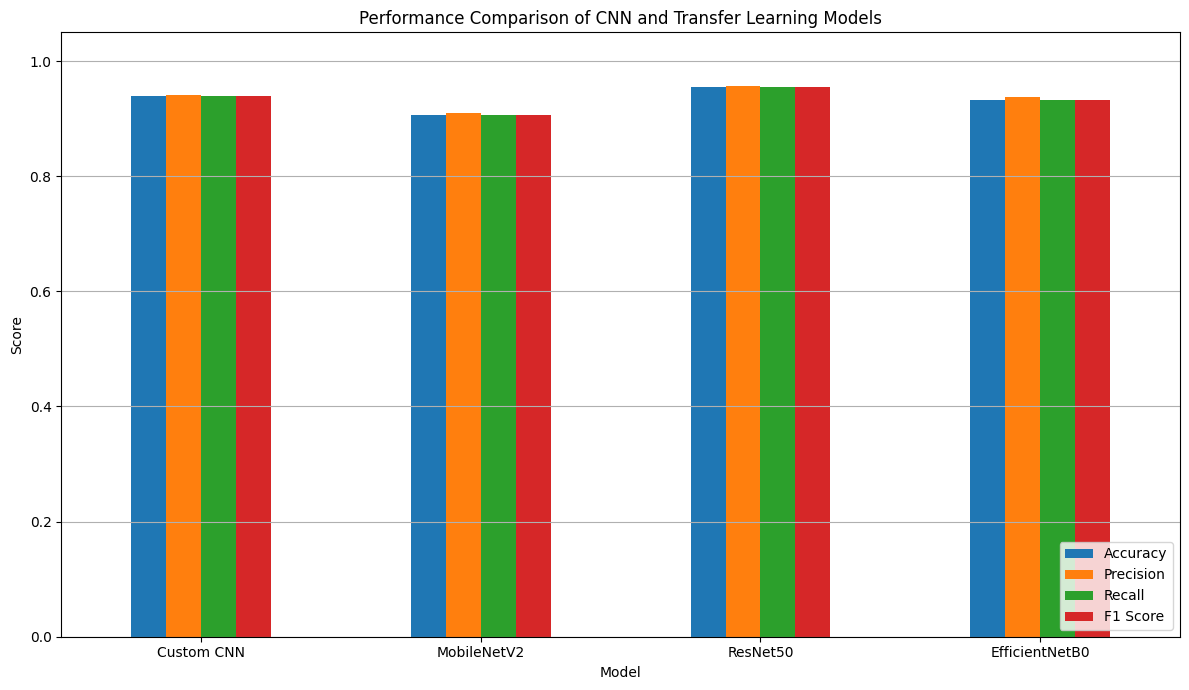

In [57]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

comparison_data = all_results.set_index(
    "Model"
)[metrics]

comparison_data.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Performance Comparison of CNN and Transfer Learning Models"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

**Training Time & Model Complexity**

Note:
Training time and parameter count are compared to evaluate the computational efficiency and complexity of each model.

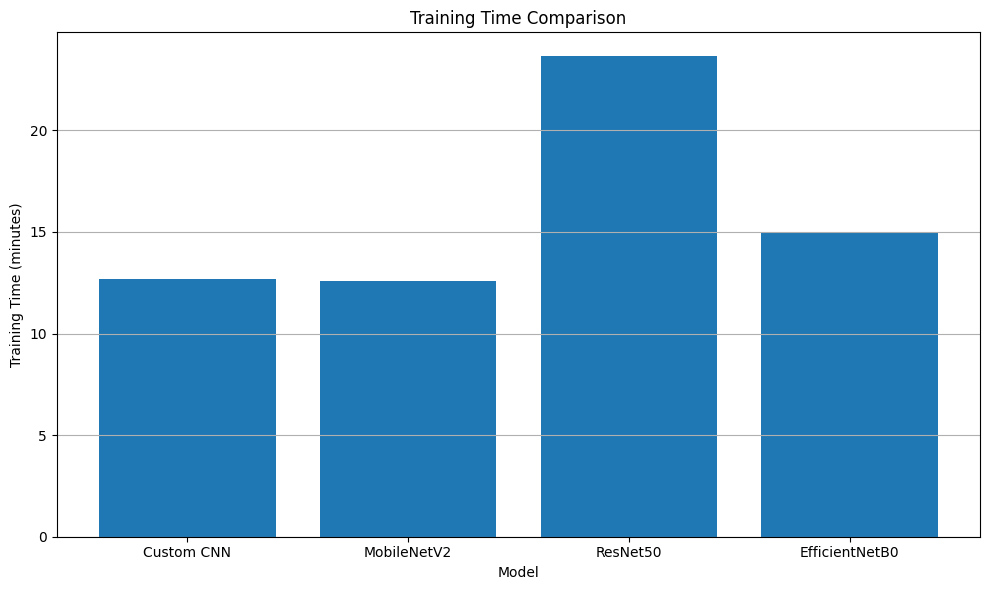

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(
    all_results["Model"],
    all_results["Training Time (min)"]
)

plt.title(
    "Training Time Comparison"
)

plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

Parameter Count

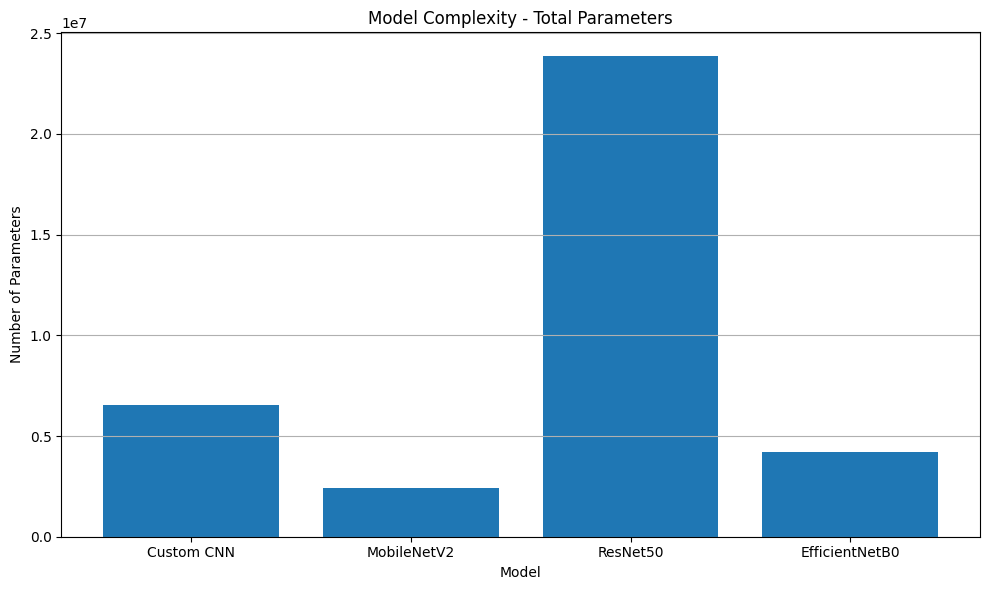

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    all_results["Model"],
    all_results["Total Parameters"]
)

plt.title(
    "Model Complexity - Total Parameters"
)

plt.xlabel("Model")
plt.ylabel("Number of Parameters")

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

**Automatic Comparative Summary**

Note:
This summary provides a concise interpretation of the experimental results and identifies the best-performing approach based on the obtained metrics.

In [61]:
print("==============================================")
print("COMPARATIVE STUDY SUMMARY")
print("==============================================\n")

for _, row in all_results.iterrows():

    print(
        f"{row['Model']}: "
        f"Accuracy = {row['Accuracy'] * 100:.2f}%, "
        f"Precision = {row['Precision'] * 100:.2f}%, "
        f"Recall = {row['Recall'] * 100:.2f}%, "
        f"F1 = {row['F1 Score'] * 100:.2f}%"
    )

print("\n----------------------------------------------")

# Find the best performing model based on accuracy
best_accuracy = 0
best_accuracy_model = ""

for index, row in all_results.iterrows():
    if row["Accuracy"] > best_accuracy:
        best_accuracy = row["Accuracy"]
        best_accuracy_model = row["Model"]

# Find the best performing model based on F1-score
best_f1 = 0
best_f1_model = ""

for index, row in all_results.iterrows():
    if row["F1 Score"] > best_f1:
        best_f1 = row["F1 Score"]
        best_f1_model = row["Model"]

print(
    f"\nBest performing model based on accuracy: "
    f"{best_accuracy_model}"
)

print(
    f"Test Accuracy: "
    f"{best_accuracy * 100:.2f}%"
)

print(
    f"\nBest performing model based on F1-score: "
    f"{best_f1_model}"
)

print(
    f"F1 Score: "
    f"{best_f1 * 100:.2f}%"
)

COMPARATIVE STUDY SUMMARY

Custom CNN: Accuracy = 93.89%, Precision = 94.11%, Recall = 93.89%, F1 = 93.92%
MobileNetV2: Accuracy = 90.58%, Precision = 91.06%, Recall = 90.58%, F1 = 90.56%
ResNet50: Accuracy = 95.48%, Precision = 95.64%, Recall = 95.48%, F1 = 95.51%
EfficientNetB0: Accuracy = 93.17%, Precision = 93.81%, Recall = 93.17%, F1 = 93.30%

----------------------------------------------

Best performing model based on accuracy: ResNet50
Test Accuracy: 95.48%

Best performing model based on F1-score: ResNet50
F1 Score: 95.51%


**Final Conclusion**

Note:
The conclusion summarizes the comparative experiment by considering predictive performance, computational complexity, and the advantages and limitations of training CNNs from scratch versus transfer learning.

## Final Conclusion

The experiment compared a Custom CNN trained from scratch with three
pretrained transfer-learning models: MobileNetV2, ResNet50, and
EfficientNetB0 for tomato leaf disease classification.

All four models were trained and evaluated using the same PlantVillage
tomato dataset, consisting of 10 disease/healthy classes, with the same
training, validation, and testing strategy.

The Custom CNN successfully learned discriminative features directly
from the tomato leaf images and achieved competitive classification
performance. However, training a CNN from scratch generally requires
more task-specific learning and may be more sensitive to dataset size
and class imbalance.

The pretrained models benefited from features learned from the ImageNet
dataset. Feature extraction followed by fine-tuning allowed the models
to adapt these learned representations to tomato leaf disease
classification.

Among the evaluated approaches, the model with the highest test accuracy
and F1-score is considered the best-performing model for this experiment.
The final model selection should also consider training time and number
of parameters when computational efficiency is important.

Overall, the experiment demonstrates that transfer learning can provide
a strong alternative to training CNNs completely from scratch, while
the Custom CNN provides a useful baseline for comparison.